In [4]:
import numpy as np
import matplotlib.pyplot as plt

def superGauss(f, n, B_3dB):
    '''
    Calculates the supergaussian filter frequency response for a given order n and 3dB bandwidth B_3dB.

    param:
        f (np.array): Frequency array (in Hz) for which to calculate the filter response.
        n (int): Order of the supergaussian filter.
        B_3dB (float): 3dB bandwidth of the filter (in Hz).
    
    return:
        H_sg (np.array): Frequency response of the supergaussian filter at the given frequencies.
    '''

    alpha = np.log(2)/2
    H_sg = np.exp(-alpha * (f / B_3dB)**(2*n))
    return H_sg

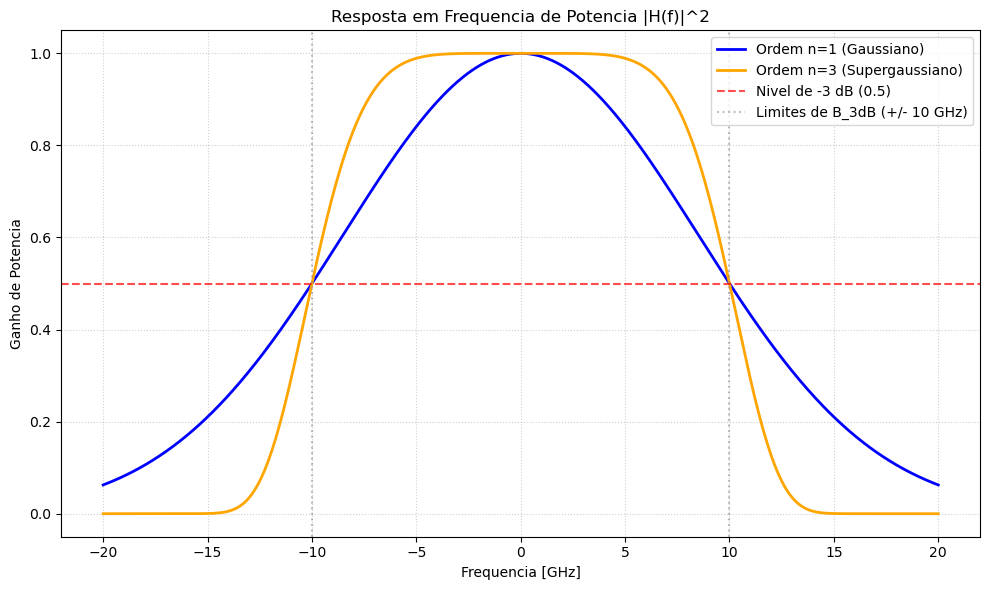

In [8]:
B_3dB = 10e9       
Fs = 40e9          
f = np.linspace(-Fs/2, Fs/2, 1000)  

H_n1 = superGauss(f, n=1, B_3dB=B_3dB)
H_n3 = superGauss(f, n=3, B_3dB=B_3dB)

H_n1_pot = H_n1**2
H_n3_pot = H_n3**2

plt.figure(figsize=(10, 6))

plt.plot(f / 1e9, H_n1_pot, label='Ordem n=1 (Gaussiano)', color='blue', linewidth=2)
plt.plot(f / 1e9, H_n3_pot, label='Ordem n=3 (Supergaussiano)', color='orange', linewidth=2)

plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Nivel de -3 dB (0.5)')
plt.axvline(-B_3dB / 1e9, color='gray', linestyle=':', alpha=0.5)
plt.axvline(B_3dB / 1e9, color='gray', linestyle=':', alpha=0.5, label='Limites de B_3dB (+/- 10 GHz)')

plt.title('Resposta em Frequencia de Potencia |H(f)|^2')
plt.xlabel('Frequencia [GHz]')
plt.ylabel('Ganho de Potencia')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [1]:
def H_CD(f, D, L, fc):
    """
    Obtains the frequency response of chromatic disperion of a linear fiber

    param:
        f(np.array): frequency vector in Hz
        D(float): CD parameter of the fiber
        L(float): Length of the fiber channel
        fc(float): Central frequency of optical signal
    returns:
        H_cd(np.array): Frequency coefficients of linear fiber response
    """
    c = 299792458
    H_cd = np.cos(np.pi*c*D*L* (f/fc)**2)

    return H_cd